# What is an outlier?
An outlier is a data point in a data set that is distant from all other observations. A data point that lies outside the overall distribution of the dataset.

### What are the criteria to identify an outlier?

1. Data point that falls outside of 1.5 times of an interquartile range above the 3rd quartile and below the 1st quartile
2. Data point that falls outside of 3 standard deviations. we can use a z score and if the z score falls outside of 2 standard deviation

### What is the reason for an outlier to exists in a dataset?

1. Variability in the data
2. An experimental measurement error

### What are the impacts of having outliers in a dataset?

1. It causes various problems during our statistical analysis
2. It may cause a significant impact on the mean and the standard deviation

### Various ways of finding the outlier.
1. Using scatter plots
2. Box plot
3. using z score
4. using the IQR interquantile range
5. Clustering



In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Detecting outlier using Scatter plots


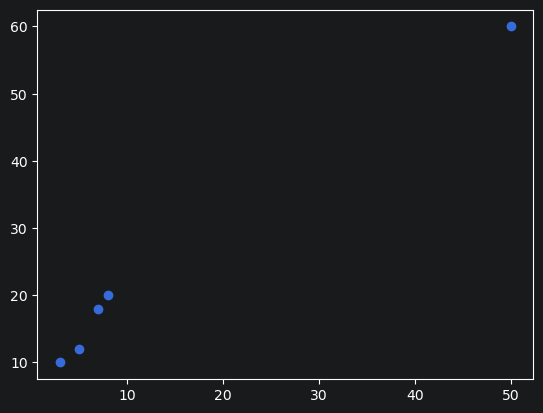

In [3]:
x = [3, 5, 7, 8, 50]
y = [10, 12, 18, 20, 60]

plt.scatter(x, y)
plt.show()

# 2. Detecting outlier using Box plots

<Axes: >

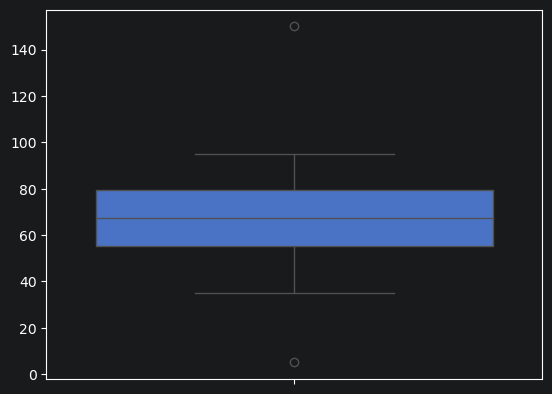

In [5]:
data = [5, 35, 50, 60, 70, 80, 65, 55, 78, 56, 75, 80, 95, 150]
sns.boxplot(data=data)

# 3. Detecting outlier using Z score

### Using Z score
Observation: Each data point/ individual data point

Formula for Z score = (Observation — Mean)/Standard Deviation

z = (X — μ) / σ

In [7]:
dataset = [1, 2, 3, 4, 5, 6, 8, 10, -50]
outliers = []


def detect_outliers(dataset):
    threshold = 2
    mean = np.mean(dataset)
    std = np.std(dataset)

    for x in dataset:
        z_score = (x - mean) / std
        if np.abs(z_score) > threshold:
            outliers.append(x)
    return outliers


print(detect_outliers(dataset))

[-50]


# 4. Detecting outlier using std

In [8]:
dataset = [1, 2, 3, 4, 5, 4, 3, 2, 1, 70]
outliers = []


def detect_outliers(dataset):
    mean = np.mean(dataset)
    std = np.mean(dataset)
    lb = mean - 2 * std
    ub = mean + 2 * std
    for x in dataset:
        if x < lb or x > ub:
            outliers.append(x)
    return outliers


print(detect_outliers(dataset))

[70]


## 5.  InterQuantile Range

Q3:75%- Q1:25% values in a dataset

### Steps
#### 1. Arrange the data in increasing order
#### 2. Calculate first(q1) and third quartile(q3)
#### 3. Find interquartile range (q3-q1)
#### 4.Find lower bound : q1- iqr*1.5
#### 5.Find upper bound :q3 + iqr*1.5

Anything that lies outside of lower and upper bound is an outlier

In [11]:
dataset = [1, 2, 3, 4, 5, 6, 8, 10, 75, -20]
Q1 = np.percentile(dataset, 25)
Q3 = np.percentile(dataset, 75)
iqr = Q3 - Q1
print(iqr)

5.25


In [12]:
## Find the lower bound value and the higher bound value
lower_bound_val = Q1 - (1.5 * iqr)
upper_bound_val = Q3 + (1.5 * iqr)

In [13]:
def detect_outliers(data):
    outliers = []
    for x in data:
        if x < lower_bound_val or x > upper_bound_val:
            outliers.append(x)
    return outliers


detect_outliers(dataset)

[75, -20]